In [1]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

In [2]:
reference_text = """
Natural language processing (NLP) enables computers to understand, interpret, and generate human language. 
Text summarization is a key task in NLP, helping condense large texts into concise summaries while preserving essential meaning.
"""

In [3]:
model_list = [
    "facebook/bart-large-cnn",  # BART
    "google/pegasus-xsum",      # Pegasus
    "t5-base",                  # T5
    "t5-large",                 # T5 Large
]

summaries = {}
evaluation_scores = {}

In [7]:
def summarize_text(model_name, text):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    # Tokenize input text and generate summary
    inputs = tokenizer.encode(text, return_tensors="pt", max_length=512, truncation=True)
    summary_ids = model.generate(inputs, max_length=130, min_length=30, length_penalty=2.0, num_beams=4)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    return summary

In [8]:
def evaluate_summary(reference, summary):
    # Tokenize reference and summary text
    reference_tokens = word_tokenize(reference.lower())
    summary_tokens = word_tokenize(summary.lower())
    
    # Calculate BLEU score
    bleu_score = sentence_bleu([reference_tokens], summary_tokens)
    
    # Calculate ROUGE scores
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = rouge.score(reference, summary)
    
    return {
        "BLEU": bleu_score,
        "ROUGE-1": rouge_scores['rouge1'].fmeasure,
        "ROUGE-2": rouge_scores['rouge2'].fmeasure,
        "ROUGE-L": rouge_scores['rougeL'].fmeasure,
    }

In [9]:
for model_name in model_list:
    print(f"Summarizing with {model_name}...")
    summary = summarize_text(model_name, reference_text)
    summaries[model_name] = summary
    
    print(f"Evaluating summary from {model_name}...")
    scores = evaluate_summary(reference_text, summary)
    evaluation_scores[model_name] = scores

Summarizing with facebook/bart-large-cnn...
Evaluating summary from facebook/bart-large-cnn...
Summarizing with google/pegasus-xsum...


tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Evaluating summary from t5-large...


In [10]:
print("\nSummaries and Evaluation Scores:")
for model_name in model_list:
    print(f"\nModel: {model_name}")
    print(f"Summary: {summaries[model_name]}")
    print(f"Evaluation Scores: {evaluation_scores[model_name]}")


Summaries and Evaluation Scores:

Model: facebook/bart-large-cnn
Summary: Natural language processing (NLP) enables computers to understand, interpret, and generate human language. NLP helps condense large texts into concise summaries while preserving essential meaning.
Evaluation Scores: {'BLEU': 0.6846245620372664, 'ROUGE-1': 0.8771929824561403, 'ROUGE-2': 0.8363636363636364, 'ROUGE-L': 0.8771929824561403}

Model: google/pegasus-xsum
Summary: Researchers at the Massachusetts Institute of Technology (MIT) have developed a machine learning technique that can summarize large amounts of text in a fraction of the time it would take a human to do so.
Evaluation Scores: {'BLEU': 1.2379247604754229e-231, 'ROUGE-1': 0.20895522388059704, 'ROUGE-2': 0.0, 'ROUGE-L': 0.08955223880597014}

Model: t5-base
Summary: Natural language processing (NLP) enables computers to understand, interpret, and generate human language. Text summarization is a key task in NLP, helping condense large texts into conc

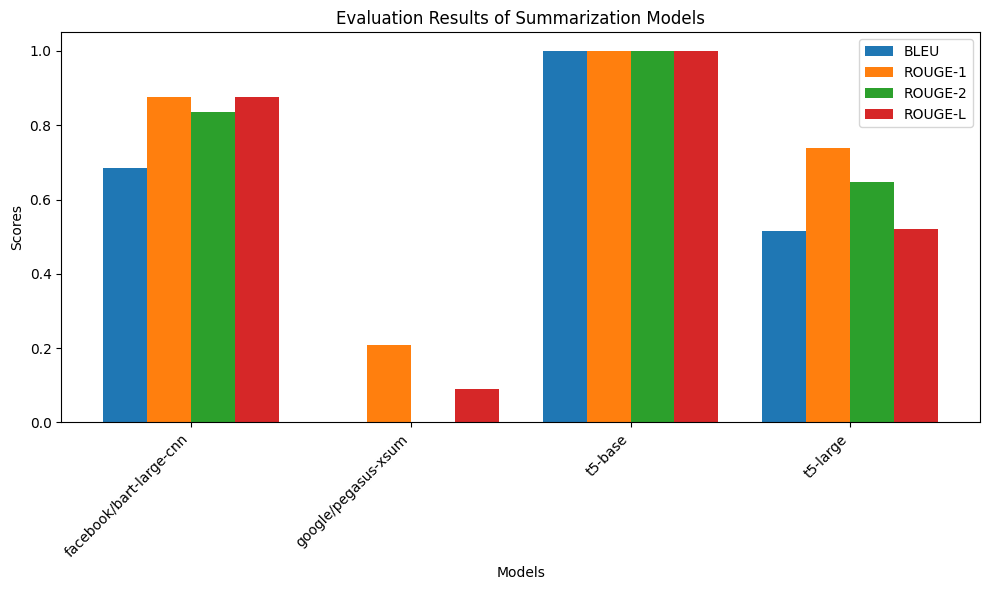

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for visualization
models = list(evaluation_scores.keys())
metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]
data = {metric: [evaluation_scores[model][metric] for model in models] for metric in metrics}

# Plotting the evaluation results
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, data[metric], width, label=metric)

# Add labels, title, and legend
ax.set_xlabel("Models")
ax.set_ylabel("Scores")
ax.set_title("Evaluation Results of Summarization Models")
ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()